<a href="https://colab.research.google.com/github/Sangamithradillibabu/HOUSEPRICE_PREDICTION/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.8287000000178814 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.6.17  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.7      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.22.1     pyhcf101f3_0         conda-forge
+ pandas              3.0.3      np23py313h1e705a5_0  emscripten-forge-4x
+ patsy               1.0.2      py313h1804a44_3      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import os
print(os.listdir())

['Housing.csv', 'Untitled1.ipynb', 'analysis.ipynb', 'untitled.py', 'notebooks', 'README.md', 'data']


In [ ]:
import pandas as pd

df = pd.read_csv("Housing.csv")
df.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [ ]:
df.info

<bound method DataFrame.info of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no

In [ ]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [ ]:
df.shape


(545, 13)

In [ ]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
df["price"].head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [ ]:
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df = df.replace({"yes": 1, "no": 0})

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"MAE  : {mae_lr:,.0f}")
print(f"RMSE : {rmse_lr:,.0f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression
MAE  : 960,791
RMSE : 1,326,399
R²   : 0.6519


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print(f"MAE  : {mae_rf:,.0f}")
print(f"RMSE : {rmse_rf:,.0f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Regressor
MAE  : 1,022,136
RMSE : 1,405,406
R²   : 0.6092


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting")
print(f"MAE  : {mae_gbr:,.0f}")
print(f"RMSE : {rmse_gbr:,.0f}")
print(f"R²   : {r2_gbr:.4f}")

Gradient Boosting
MAE  : 1,022,056
RMSE : 1,371,665
R²   : 0.6278


In [ ]:
comparison = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest'],
    'MAE':    [round(mae_lr, 2),  round(mae_rf, 2)],
    'RMSE':   [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R² Score':[round(r2_lr, 4),  round(r2_rf, 4)]
})

print(comparison.to_string(index=False))
winner = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print(f"\nBetter model: {winner}")

            Model        MAE       RMSE  R² Score
Linear Regression  960791.41 1326399.01    0.6519
    Random Forest 1022135.71 1405406.33    0.6092

Better model: Linear Regression


In [ ]:
import os
os.makedirs('charts', exist_ok=True)
print("Done:", os.path.abspath('charts'))

Done: /drive/charts


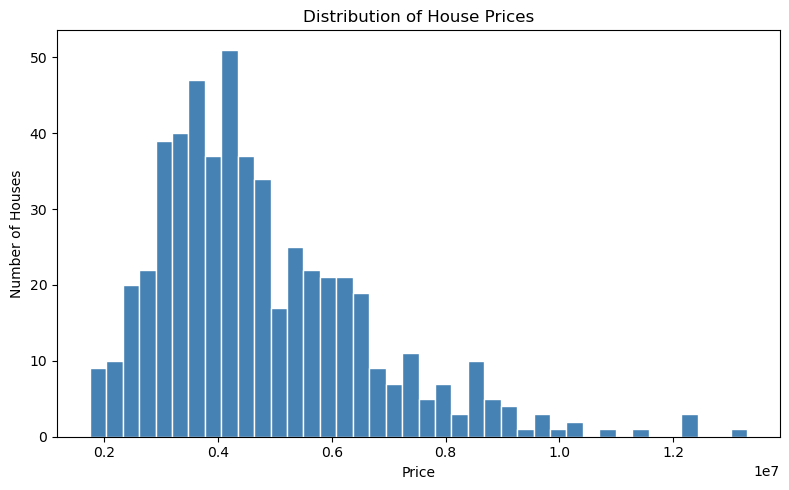

 saved.


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" saved.")

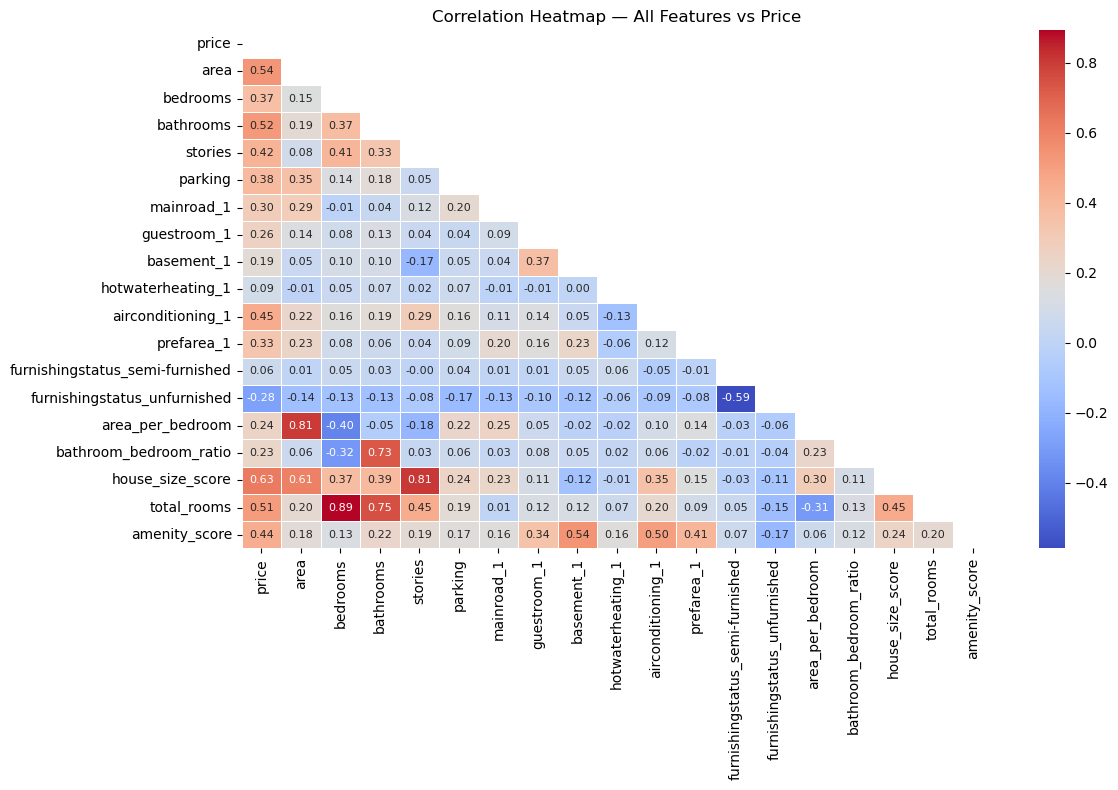

saved.


In [ ]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Heatmap — All Features vs Price')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved.")

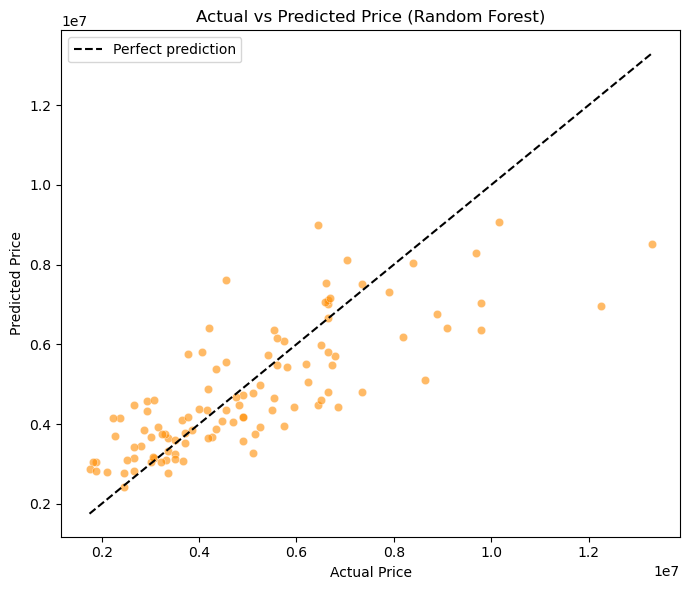

saved.


In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='darkorange', edgecolors='white', linewidth=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5, label='Perfect prediction')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved.")

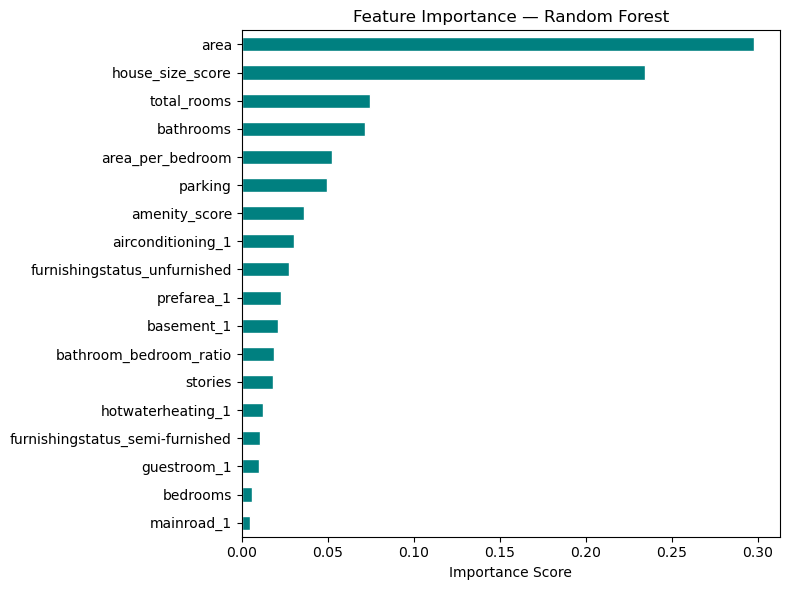


Top 3 most important features:
area                0.298171
house_size_score    0.234334
total_rooms         0.074470
dtype: float64


In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
print(feat_imp.sort_values(ascending=False).head(3))

In [ ]:
# FEATURE ENGINEERING

In [ ]:

df["area_per_bedroom"] = df["area"] / df["bedrooms"].replace(0, 1)
df["bathroom_bedroom_ratio"] = df["bathrooms"] / df["bedrooms"].replace(0, 1)
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [ ]:

df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop("price", axis=1)
y = df_model["price"]

In [ ]:
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print(corr.head(15))

price                     1.000000
house_size_score          0.626566
area                      0.535997
bathrooms                 0.517545
total_rooms               0.511809
airconditioning_1         0.452954
amenity_score             0.442199
stories                   0.420712
parking                   0.384394
bedrooms                  0.366494
prefarea_1                0.329777
mainroad_1                0.296898
guestroom_1               0.255517
area_per_bedroom          0.244809
bathroom_bedroom_ratio    0.231732
Name: price, dtype: float64


In [ ]:
df["luxury_score"] = (
    df["airconditioning_1"]
    + df["hotwaterheating_1"]
    + df["prefarea_1"]
)

In [ ]:
df["house_size_score"] = df["area"] * df["stories"]

df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

df["amenity_score"] = (
    df["airconditioning_1"]
    + df["guestroom_1"]
    + df["basement_1"]
    + df["hotwaterheating_1"]
    + df["prefarea_1"]
)

In [ ]:
### Several derived features were engineered, including house_size_score, total_rooms, and amenity_score. Although house_size_score showed the strongest correlation with price (0.627), incorporating these engineered features did not improve the RANDOMFOREST's R² score AND LINEAR REGRESSION. This suggests that the original features already captured most of the predictive information and that the engineered features introduced redundancy rather than additional signal.

In [ ]:
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print(corr.head(20))

price                              1.000000
house_size_score                   0.626566
area                               0.535997
bathrooms                          0.517545
total_rooms                        0.511809
luxury_score                       0.505162
airconditioning_1                  0.452954
amenity_score                      0.442199
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_1                         0.329777
mainroad_1                         0.296898
guestroom_1                        0.255517
area_per_bedroom                   0.244809
bathroom_bedroom_ratio             0.231732
basement_1                         0.187057
hotwaterheating_1                  0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:(AFTER FEATURE)", r2_score(y_test, y_pred))

R2 Score:(AFTER FEATURE) 0.6177669313152743


In [ ]:

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression R² (After Feature Engineering):")
print(r2_score(y_test, y_pred))

Linear Regression R² (After Feature Engineering):
0.6517717248155167


In [ ]:
###  Insights & Summary

After analyzing the housing dataset and building different machine learning models, I found that the size of the house (area) had the biggest impact on house prices. Other important factors included the number of bathrooms, availability of air conditioning, parking space, and the number of stories. In general, houses that were larger and offered more amenities tended to have higher prices.

To predict house prices, I trained Linear Regression and Random Forest models. The Linear Regression model performed the best with an R² score of approximately 0.65. This means that the model was able to explain about 65% of the variation in house prices. While the predictions were not perfect, the model was reasonably accurate and provided a good estimate of property values based on the available features.

One thing that surprised me was the result of feature engineering. I created new features such as house_size_score and total_rooms, expecting them to improve the model's accuracy. Although these new features showed strong relationships with house prices, they did not significantly improve the model's performance. This was an interesting finding because it showed that creating more features does not always lead to better predictions.

Based on the results of this analysis, I would recommend that real estate businesses focus on properties with larger areas, sufficient bathrooms, parking facilities, and modern amenities such as air conditioning. These features were consistently associated with higher house prices and appear to be key factors that buyers value when purchasing a home.

Overall, this project helped me understand the complete machine learning workflow, including data cleaning, visualization, model building, evaluation, and feature engineering. It also demonstrated how data can be used to make informed decisions in the real estate industry.
